In [1]:
import os

os.listdir('/content')

['.config', '.ipynb_checkpoints', 'ecommerce_sales_dataset.zip', 'sample_data']

In [4]:
import zipfile

zip_path = "/content/ecommerce_sales_dataset.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/ecommerce_data")

In [5]:
import os

os.listdir("/content/ecommerce_data")

['products.csv',
 'customers.csv',
 'clean_final_data.csv',
 'payments.csv',
 'orders.csv']

In [7]:
import pandas as pd

df = pd.read_csv("/content/ecommerce_data/clean_final_data.csv")



In [8]:
df.head()


,OrderID,CustomerID,OrderDate,ProductID,Quantity,Discount,PaymentMethod,Status,Age,City,SignupDate,CustomerSegment,ProductName,Category,UnitPrice,Sales,OrderValue
0,500001,103695,2025-08-28,2003,4.0,10.0,Gateway,Completed,36.0,Qom,2024-03-05,Regular,USB-C Cable,Accessories,9.0,32.0,32.0
1,500002,107935,2024-05-31,2014,1.0,10.0,Wallet,Completed,49.0,Kerman,2025-06-04,Regular,Backpack,Accessories,42.0,38.0,38.0
2,500003,105141,2025-08-10,2002,1.0,20.0,CardToCard,Completed,36.0,Tehran,2025-10-19,Regular,Mechanical Keyboard,Electronics,62.0,50.0,50.0
3,500004,108780,2024-10-11,2012,1.0,10.0,Gateway,Completed,45.0,Shiraz,2023-12-07,Regular,Office Chair,Home Office,180.0,162.0,162.0
4,500005,101187,2024-02-19,2008,2.0,0.0,Gateway,Completed,24.0,Karaj,2023-12-02,Regular,Phone Case,Accessories,14.0,28.0,28.0


In [9]:
df.shape

(49222, 17)

In [10]:
df.columns

Index(['OrderID', 'CustomerID', 'OrderDate', 'ProductID', 'Quantity',
       'Discount', 'PaymentMethod', 'Status', 'Age', 'City', 'SignupDate',
       'CustomerSegment', 'ProductName', 'Category', 'UnitPrice', 'Sales',
       'OrderValue'],
      dtype='object')

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49222 entries, 0 to 49221
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   OrderID          49222 non-null  int64  
 1   CustomerID       49222 non-null  int64  
 2   OrderDate        49222 non-null  object 
 3   ProductID        49222 non-null  int64  
 4   Quantity         49222 non-null  float64
 5   Discount         49222 non-null  float64
 6   PaymentMethod    49222 non-null  object 
 7   Status           49222 non-null  object 
 8   Age              49222 non-null  float64
 9   City             49222 non-null  object 
 10  SignupDate       49222 non-null  object 
 11  CustomerSegment  49222 non-null  object 
 12  ProductName      49222 non-null  object 
 13  Category         49222 non-null  object 
 14  UnitPrice        49222 non-null  float64
 15  Sales            49222 non-null  float64
 16  OrderValue       49222 non-null  float64
dtypes: float64(6

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df["OrderDate"] = pd.to_datetime(df["OrderDate"])
df["SignupDate"] = pd.to_datetime(df["SignupDate"])

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49222 entries, 0 to 49221
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          49222 non-null  int64         
 1   CustomerID       49222 non-null  int64         
 2   OrderDate        49222 non-null  datetime64[ns]
 3   ProductID        49222 non-null  int64         
 4   Quantity         49222 non-null  float64       
 5   Discount         49222 non-null  float64       
 6   PaymentMethod    49222 non-null  object        
 7   Status           49222 non-null  object        
 8   Age              49222 non-null  float64       
 9   City             49222 non-null  object        
 10  SignupDate       49222 non-null  datetime64[ns]
 11  CustomerSegment  49222 non-null  object        
 12  ProductName      49222 non-null  object        
 13  Category         49222 non-null  object        
 14  UnitPrice        49222 non-null  float

In [15]:
total_sales = df["Sales"].sum()
print("Total Sales:", total_sales)

Total Sales: 3444830.0


In [16]:
print("Total Orders:", df["OrderID"].nunique())
print("Total Customers:", df["CustomerID"].nunique())
print("Total Quantity Sold:", df["Quantity"].sum())
print("Average Order Value:", df["OrderValue"].mean())

Total Orders: 49222
Total Customers: 9820
Total Quantity Sold: 92632.0
Average Order Value: 69.98557555564585


In [17]:
product_sales = df.groupby("ProductName")["Sales"].sum().sort_values(ascending=False)

product_sales.head(10)

,Sales
ProductName,
Headphones,333411.0
Office Chair,329292.0
Tablet,292344.0
Smart Watch,259590.0
Microphone,230139.0
Mechanical Keyboard,229676.0
Bluetooth Speaker,213311.0
Gaming Controller,198037.0
Power Bank,180004.0


In [20]:
import matplotlib.pyplot as plt

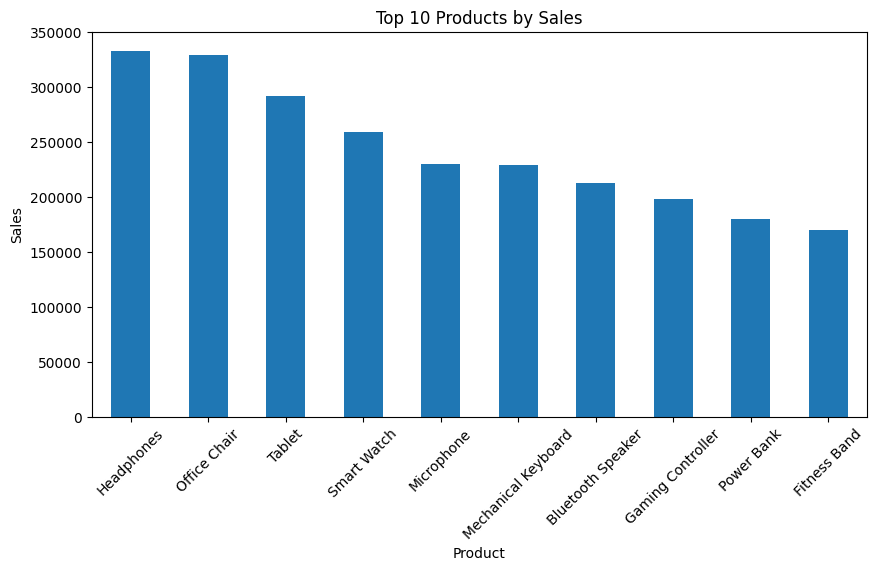

In [21]:
product_sales.head(10).plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Top 10 Products by Sales")
plt.xlabel("Product")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.show()

In [22]:
category_sales = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)

category_sales


,Sales
Category,
Electronics,1751037.0
Accessories,553023.0
Home Office,446065.0
Wearables,429450.0
Gaming,198037.0
Stationery,67218.0


In [1]:
category_sales.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.show()

NameError: name 'category_sales' is not defined

In [2]:
category_sales = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)

category_sales

NameError: name 'df' is not defined

In [3]:
import pandas as pd

df = pd.read_csv("/content/ecommerce_data/clean_final_data.csv")

In [4]:
df["OrderDate"] = pd.to_datetime(df["OrderDate"])
df["SignupDate"] = pd.to_datetime(df["SignupDate"])

In [5]:
df.shape

(49222, 17)

In [6]:
category_sales = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)

category_sales

,Sales
Category,
Electronics,1751037.0
Accessories,553023.0
Home Office,446065.0
Wearables,429450.0
Gaming,198037.0
Stationery,67218.0


NameError: name 'plt' is not defined

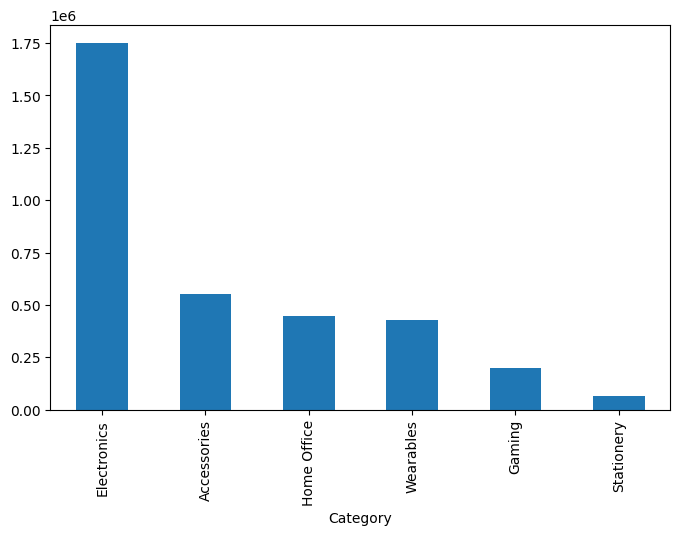

In [7]:
category_sales.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.show()

In [8]:
import matplotlib.pyplot as plt

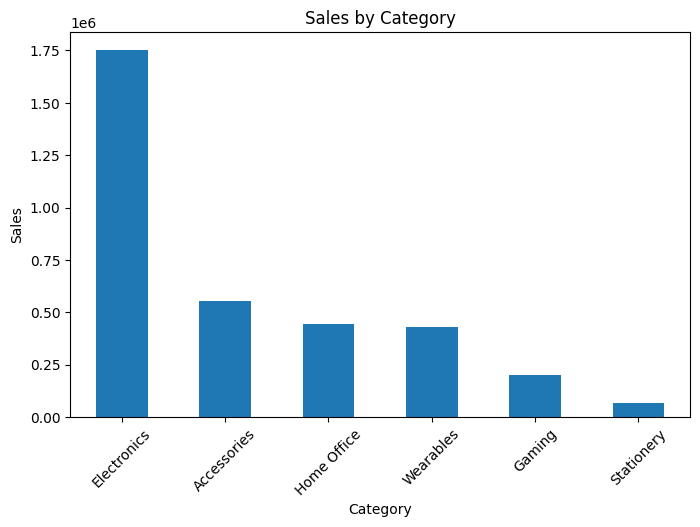

In [9]:
category_sales.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.show()

In [10]:
monthly_sales = df.groupby(
    df["OrderDate"].dt.to_period("M")
)["Sales"].sum()

monthly_sales

,Sales
OrderDate,
2024-01,121893.0
2024-02,114664.0
2024-03,128150.0
2024-04,115941.0
2024-05,123683.0
2024-06,116784.0
2024-07,128689.0
2024-08,129987.0
2024-09,115943.0


In [11]:
monthly_sales = df.groupby(
    df["OrderDate"].dt.to_period("M")
)["Sales"].sum()

monthly_sales


,Sales
OrderDate,
2024-01,121893.0
2024-02,114664.0
2024-03,128150.0
2024-04,115941.0
2024-05,123683.0
2024-06,116784.0
2024-07,128689.0
2024-08,129987.0
2024-09,115943.0


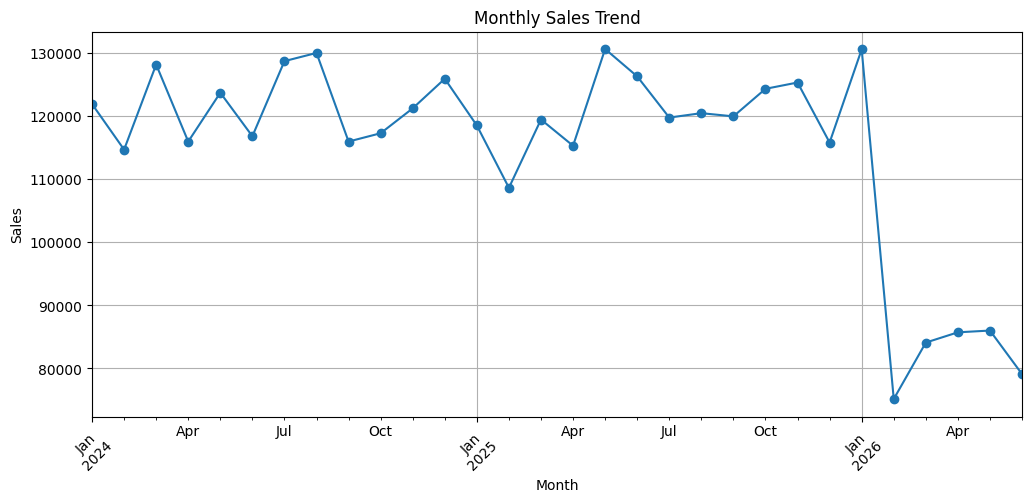

In [12]:
monthly_sales.plot(
    kind="line",
    figsize=(12, 5),
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

In [13]:
payment_sales = df.groupby("PaymentMethod")["Sales"].sum().sort_values(ascending=False)

payment_sales

,Sales
PaymentMethod,
Gateway,1667053.0
CardToCard,830572.0
Wallet,604131.0
Cash,343074.0


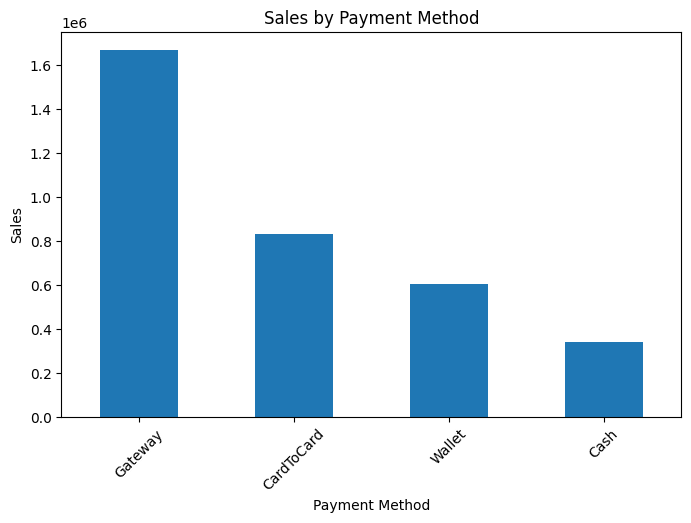

In [14]:
payment_sales.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Sales by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.show()

In [15]:
segment_sales = df.groupby("CustomerSegment")["Sales"].sum().sort_values(ascending=False)

segment_sales

,Sales
CustomerSegment,
Regular,1914854.0
New,1196104.0
VIP,333872.0


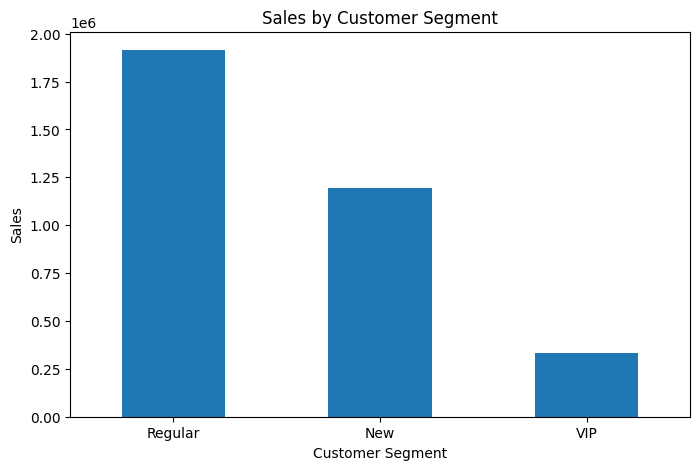

In [16]:
segment_sales.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Sales by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Sales")
plt.xticks(rotation=0)
plt.show()

In [17]:
status_count = df["Status"].value_counts()

status_count

,count
Status,
Completed,45276
Cancelled,2438
Returned,1508


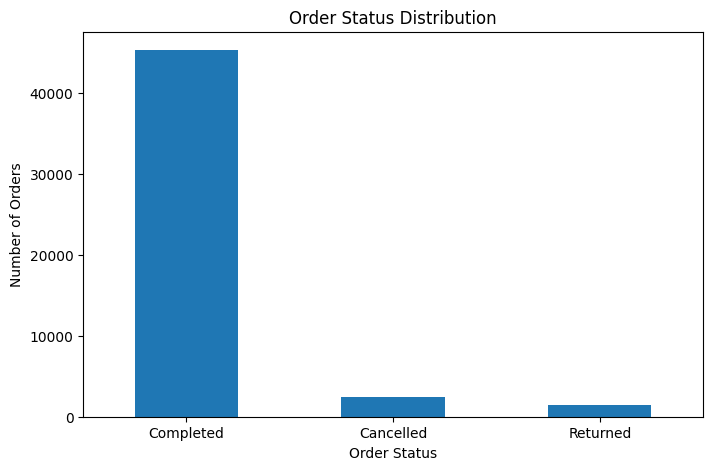

In [18]:
status_count.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Order Status Distribution")
plt.xlabel("Order Status")
plt.ylabel("Number of Orders")
plt.xticks(rotation=0)
plt.show()

In [19]:
city_sales = df.groupby("City")["Sales"].sum().sort_values(ascending=False)

city_sales.head(10)

,Sales
City,
Tehran,963907.0
Mashhad,438112.0
Karaj,350173.0
Isfahan,334531.0
Shiraz,310775.0
Tabriz,292074.0
Ahvaz,211055.0
Rasht,205882.0
Kerman,175171.0


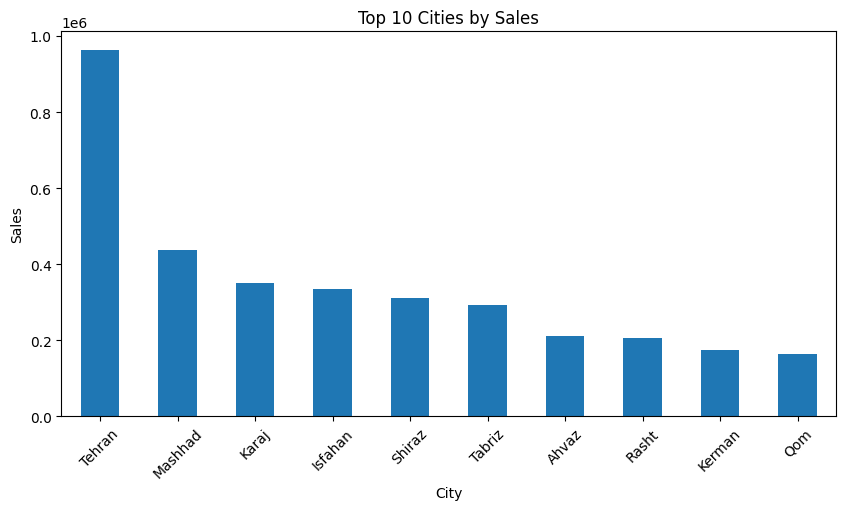

In [20]:
city_sales.head(10).plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Top 10 Cities by Sales")
plt.xlabel("City")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.show()

In [21]:
df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=[0, 18, 25, 35, 45, 55, 100],
    labels=["Below 18", "18-25", "26-35", "36-45", "46-55", "56+"]
)

age_sales = df.groupby("AgeGroup", observed=False)["Sales"].sum()

age_sales

,Sales
AgeGroup,
Below 18,66373.0
18-25,508311.0
26-35,721605.0
36-45,783604.0
46-55,681268.0
56+,683669.0


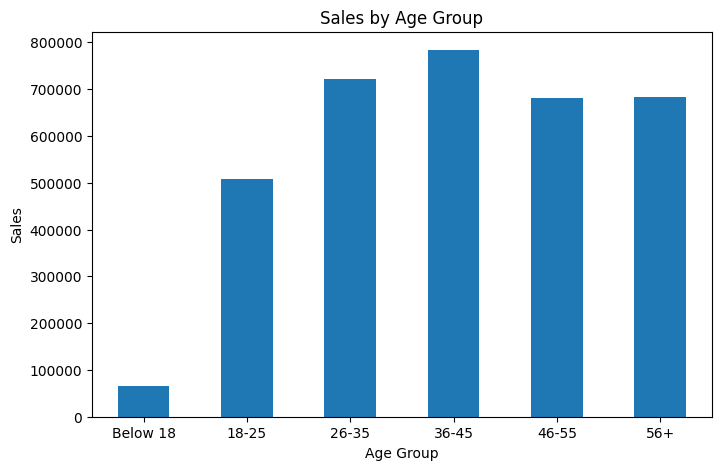

In [22]:
age_sales.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Sales by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Sales")
plt.xticks(rotation=0)
plt.show()

In [23]:
discount_sales = df.groupby("Discount")["Sales"].sum().sort_index()

discount_sales

,Sales
Discount,
0.0,1297097.0
5.0,768308.0
10.0,674145.0
15.0,382206.0
20.0,215968.0
30.0,107106.0


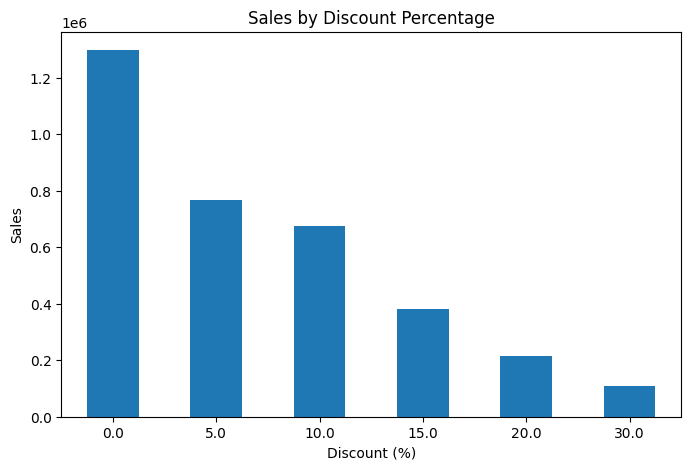

In [24]:
discount_sales.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Sales by Discount Percentage")
plt.xlabel("Discount (%)")
plt.ylabel("Sales")
plt.xticks(rotation=0)
plt.show()

In [25]:
top_customers = (
    df.groupby("CustomerID")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

top_customers.head(10)


,Sales
CustomerID,
100353,2467.0
109093,2090.0
104916,2089.0
101806,2079.0
103135,2056.0
106809,2033.0
108485,1974.0
103146,1838.0
109735,1837.0


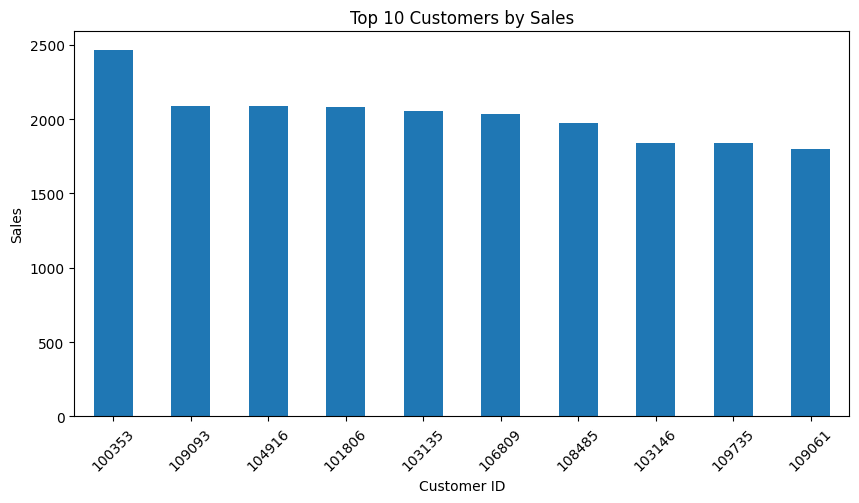

In [26]:
top_customers.head(10).plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Top 10 Customers by Sales")
plt.xlabel("Customer ID")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.show()

In [28]:
category_quantity = (
    df.groupby("Category")["Quantity"]
    .sum()
    .sort_values(ascending=False)
)

category_quantity

,Quantity
Category,
Accessories,34524.0
Electronics,33030.0
Stationery,10331.0
Home Office,5920.0
Wearables,5675.0
Gaming,3152.0


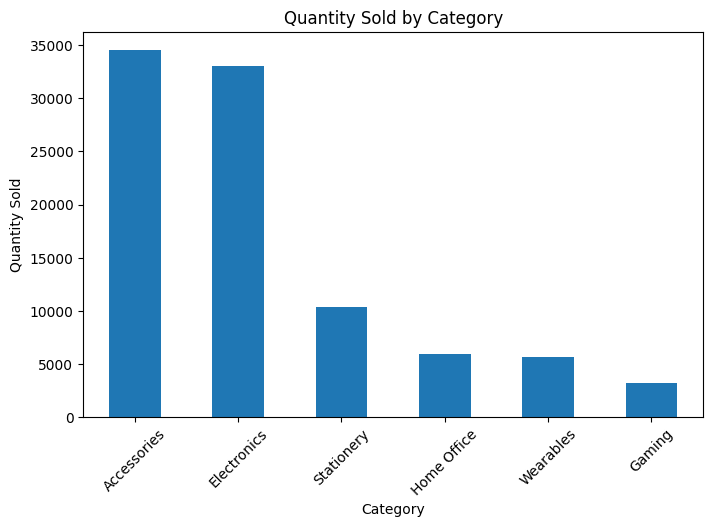

In [29]:
category_quantity.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Quantity Sold by Category")
plt.xlabel("Category")
plt.ylabel("Quantity Sold")
plt.xticks(rotation=45)
plt.show()

In [30]:
quantity_sales = df.groupby("Quantity")["Sales"].sum()

quantity_sales.head(10)

,Sales
Quantity,
-2.0,-764.0
-1.0,-176.0
0.0,0.0
1.0,890210.0
2.0,1016511.0
3.0,764914.0
4.0,495962.0
5.0,278173.0


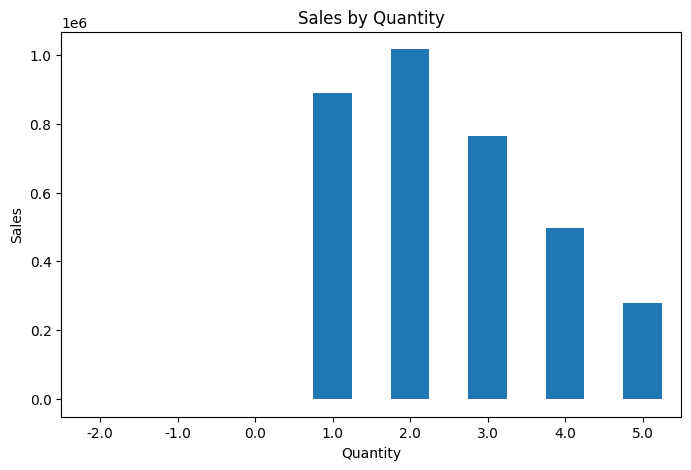

In [31]:
quantity_sales.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Sales by Quantity")
plt.xlabel("Quantity")
plt.ylabel("Sales")
plt.xticks(rotation=0)
plt.show()

In [32]:
status_sales = (
    df.groupby("Status")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

status_sales

,Sales
Status,
Completed,3162844.0
Cancelled,180171.0
Returned,101815.0


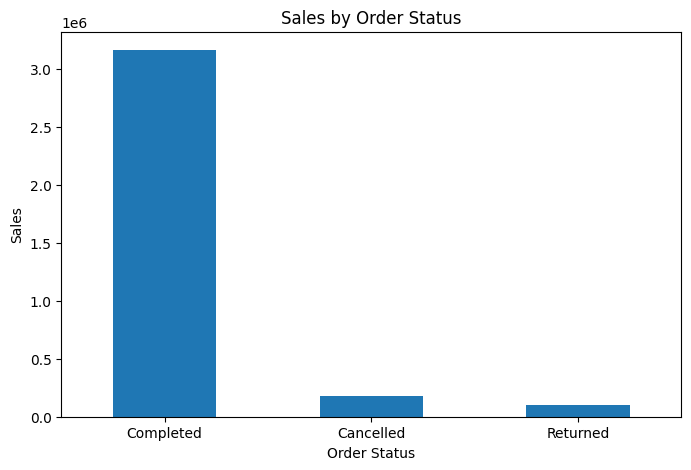

In [33]:
status_sales.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Sales by Order Status")
plt.xlabel("Order Status")
plt.ylabel("Sales")
plt.xticks(rotation=0)
plt.show()

In [34]:
yearly_sales = (
    df.groupby(df["OrderDate"].dt.year)["Sales"]
    .sum()
)

yearly_sales

,Sales
OrderDate,
2024,1460099.0
2025,1444190.0
2026,540541.0


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

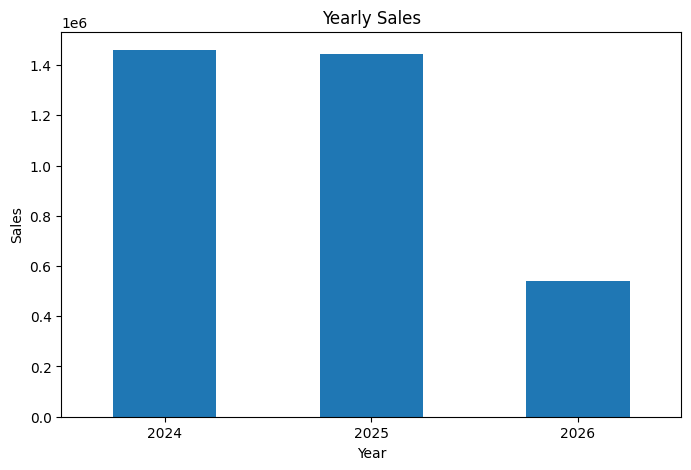

In [35]:
yearly_sales.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Yearly Sales")
plt.xlabel("Year")
plt.ylabel("Sales")
plt.xticks(rotation=0)
plt.show()

In [42]:
print("Rows:", len(df))
print("Columns:", len(df.columns))
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())
print("\nColumn names:")
print(df.columns.tolist())

Rows: 49222
Columns: 18
Missing values: 0
Duplicate rows: 0

Column names:
['OrderID', 'CustomerID', 'OrderDate', 'ProductID', 'Quantity', 'Discount', 'PaymentMethod', 'Status', 'Age', 'City', 'SignupDate', 'CustomerSegment', 'ProductName', 'Category', 'UnitPrice', 'Sales', 'OrderValue', 'AgeGroup']


In [43]:
df.dtypes

,0
OrderID,int64
CustomerID,int64
OrderDate,datetime64[ns]
ProductID,int64
Quantity,float64
Discount,float64
PaymentMethod,object
Status,object
Age,float64
City,object


In [44]:
print("Quantity:")
print(df["Quantity"].describe())

print("\nAge:")
print(df["Age"].describe())

print("\nUnit Price:")
print(df["UnitPrice"].describe())

print("\nSales:")
print(df["Sales"].describe())

print("\nOrder Value:")
print(df["OrderValue"].describe())

Quantity:
count    49222.000000
mean         1.881923
std          1.079382
min         -2.000000
25%          1.000000
50%          2.000000
75%          2.000000
max          5.000000
Name: Quantity, dtype: float64

Age:
count    49222.000000
mean        41.283369
std         13.681355
min         18.000000
25%         29.000000
50%         41.000000
75%         53.000000
max         65.000000
Name: Age, dtype: float64

Unit Price:
count    49222.000000
mean        40.286579
std         42.613062
min          7.000000
25%         11.000000
50%         28.000000
75%         58.000000
max        260.000000
Name: UnitPrice, dtype: float64

Sales:
count    49222.000000
mean        69.985576
std         94.483273
min       -170.000000
25%         17.000000
50%         38.000000
75%         84.000000
max       1300.000000
Name: Sales, dtype: float64

Order Value:
count    49222.000000
mean        69.985576
std         94.483273
min       -170.000000
25%         17.000000
50%         38.000

In [45]:
print("Negative Quantity:", (df["Quantity"] < 0).sum())
print("Negative Sales:", (df["Sales"] < 0).sum())

print("\nNegative Quantity by Status:")
print(df[df["Quantity"] < 0]["Status"].value_counts())

print("\nNegative Sales by Status:")
print(df[df["Sales"] < 0]["Status"].value_counts())

Negative Quantity: 19
Negative Sales: 19

Negative Quantity by Status:
Status
Completed    18
Cancelled     1
Name: count, dtype: int64

Negative Sales by Status:
Status
Completed    18
Cancelled     1
Name: count, dtype: int64


In [46]:
negative_records = df[df["Quantity"] < 0]

negative_records[
    [
        "OrderID",
        "Quantity",
        "UnitPrice",
        "Discount",
        "Sales",
        "OrderValue",
        "Status",
        "ProductName",
        "Category"
    ]
]

,OrderID,Quantity,UnitPrice,Discount,Sales,OrderValue,Status,ProductName,Category
406,500414,-1.0,11.0,0.0,-11.0,-11.0,Completed,HDMI Cable,Accessories
2956,503005,-2.0,9.0,0.0,-18.0,-18.0,Completed,USB-C Cable,Accessories
3362,503416,-1.0,7.0,10.0,-6.0,-6.0,Completed,Notebook,Stationery
3895,503960,-1.0,9.0,5.0,-9.0,-9.0,Completed,USB-C Cable,Accessories
9055,509199,-2.0,85.0,0.0,-170.0,-170.0,Completed,Microphone,Electronics
9946,510103,-2.0,68.0,5.0,-129.0,-129.0,Completed,Gaming Controller,Gaming
10861,511036,-1.0,7.0,10.0,-6.0,-6.0,Completed,Notebook,Stationery
12618,512820,-1.0,18.0,5.0,-17.0,-17.0,Completed,Wireless Mouse,Electronics
13110,513318,-1.0,42.0,0.0,-42.0,-42.0,Completed,Backpack,Accessories
19262,519585,-1.0,7.0,0.0,-7.0,-7.0,Completed,Notebook,Stationery


In [47]:
id="e3h1yz"
calculated_sales = (
    df["Quantity"] *
    df["UnitPrice"] *
    (1 - df["Discount"] / 100)
)

difference = df["Sales"] - calculated_sales

print("Maximum difference:", difference.abs().max())
print("Rows with difference:", (difference.abs() > 0.01).sum())

Maximum difference: 0.5
Rows with difference: 28012


In [48]:
difference.abs().describe()

,0
count,49222.000000
mean,0.162942
std,0.171282
min,0.000000
25%,0.000000
50%,0.100000
75%,0.300000
max,0.500000


In [49]:
print(difference.abs().value_counts().sort_index().head(20))

0.000000e+00    21140
7.105427e-15        1
1.421085e-14       40
2.842171e-14       22
5.684342e-14        5
1.136868e-13        2
5.000000e-02      336
5.000000e-02      426
1.000000e-01      334
1.000000e-01      887
1.000000e-01     1285
1.000000e-01      126
1.000000e-01      968
1.500000e-01      161
1.500000e-01       21
2.000000e-01      781
2.000000e-01     1217
2.000000e-01     2416
2.000000e-01      162
2.000000e-01      411
Name: count, dtype: int64


In [50]:
calculated_sales_rounded = (
    df["Quantity"] *
    df["UnitPrice"] *
    (1 - df["Discount"] / 100)
).round()

difference_rounded = df["Sales"] - calculated_sales_rounded

print("Maximum difference:", difference_rounded.abs().max())
print("Rows with difference:", (difference_rounded.abs() > 0.01).sum())

Maximum difference: 0.0
Rows with difference: 0


In [51]:
print("Order Date Range:")
print("First:", df["OrderDate"].min())
print("Last:", df["OrderDate"].max())

print("\nSignup Date Range:")
print("First:", df["SignupDate"].min())
print("Last:", df["SignupDate"].max())

print("\nInvalid Order Dates:", df["OrderDate"].isna().sum())
print("Invalid Signup Dates:", df["SignupDate"].isna().sum())

Order Date Range:
First: 2024-01-01 00:00:00
Last: 2026-06-30 00:00:00

Signup Date Range:
First: 2023-01-01 00:00:00
Last: 2025-12-30 00:00:00

Invalid Order Dates: 0
Invalid Signup Dates: 0


In [52]:
print("Order Statuses:")
print(df["Status"].value_counts())

print("\nNumber of unique statuses:", df["Status"].nunique())
print("\nStatus names:")
print(df["Status"].unique())


Order Statuses:
Status
Completed    45276
Cancelled     2438
Returned      1508
Name: count, dtype: int64

Number of unique statuses: 3

Status names:
['Completed' 'Returned' 'Cancelled']


In [53]:
print("Payment Methods:")
print(df["PaymentMethod"].value_counts())

print("\nNumber of unique payment methods:", df["PaymentMethod"].nunique())

print("\nPayment method names:")
print(df["PaymentMethod"].unique())

Payment Methods:
PaymentMethod
Gateway       23894
CardToCard    11744
Wallet         8661
Cash           4923
Name: count, dtype: int64

Number of unique payment methods: 4

Payment method names:
['Gateway' 'Wallet' 'CardToCard' 'Cash']


In [54]:
print("Customer Segments:")
print(df["CustomerSegment"].value_counts())

print("\nNumber of unique customer segments:",
      df["CustomerSegment"].nunique())

print("\nCustomer segment names:")
print(df["CustomerSegment"].unique())

Customer Segments:
CustomerSegment
Regular    27296
New        17056
VIP         4870
Name: count, dtype: int64

Number of unique customer segments: 3

Customer segment names:
['Regular' 'New' 'VIP']


In [55]:
print("Product Categories:")
print(df["Category"].value_counts())

print("\nNumber of unique categories:",
      df["Category"].nunique())

print("\nCategory names:")
print(df["Category"].unique())

Product Categories:
Category
Accessories    18189
Electronics    17765
Stationery      5440
Home Office     3122
Wearables       3043
Gaming          1663
Name: count, dtype: int64

Number of unique categories: 6

Category names:
['Accessories' 'Electronics' 'Home Office' 'Stationery' 'Wearables'
 'Gaming']


In [56]:
print("Number of unique products:", df["ProductName"].nunique())

print("\nMissing product names:", df["ProductName"].isna().sum())

print("\nProduct names:")
print(df["ProductName"].unique())

Number of unique products: 20

Missing product names: 0

Product names:
['USB-C Cable' 'Backpack' 'Mechanical Keyboard' 'Office Chair'
 'Phone Case' 'Desk Lamp' 'HDMI Cable' 'Power Bank' 'Wireless Mouse'
 'Laptop Stand' 'Notebook' 'Webcam' 'Fitness Band' 'Tablet' 'Headphones'
 'Gaming Controller' 'Microphone' 'Smart Watch' 'Bluetooth Speaker'
 'Monitor']


In [57]:
print("Number of unique cities:", df["City"].nunique())

print("\nMissing city values:", df["City"].isna().sum())

print("\nCity names:")
print(df["City"].unique())

Number of unique cities: 10

Missing city values: 0

City names:
['Qom' 'Kerman' 'Tehran' 'Shiraz' 'Karaj' 'Isfahan' 'Mashhad' 'Tabriz'
 'Rasht' 'Ahvaz']


In [58]:
print("Minimum Unit Price:", df["UnitPrice"].min())
print("Maximum Unit Price:", df["UnitPrice"].max())

print("\nZero or negative prices:",
      (df["UnitPrice"] <= 0).sum())

print("\nMissing prices:",
      df["UnitPrice"].isna().sum())

Minimum Unit Price: 7.0
Maximum Unit Price: 260.0

Zero or negative prices: 0

Missing prices: 0


In [59]:
print("Minimum Discount:", df["Discount"].min())
print("Maximum Discount:", df["Discount"].max())

print("\nNegative discounts:",
      (df["Discount"] < 0).sum())

print("\nMissing discounts:",
      df["Discount"].isna().sum())

print("\nDiscount values:")
print(sorted(df["Discount"].unique()))

Minimum Discount: 0.0
Maximum Discount: 30.0

Negative discounts: 0

Missing discounts: 0

Discount values:
[np.float64(0.0), np.float64(5.0), np.float64(10.0), np.float64(15.0), np.float64(20.0), np.float64(30.0)]


In [60]:
print("Minimum Quantity:", df["Quantity"].min())
print("Maximum Quantity:", df["Quantity"].max())

print("\nZero quantities:",
      (df["Quantity"] == 0).sum())

print("\nNegative quantities:",
      (df["Quantity"] < 0).sum())

print("\nMissing quantities:",
      df["Quantity"].isna().sum())

print("\nQuantity values:")
print(sorted(df["Quantity"].unique()))

Minimum Quantity: -2.0
Maximum Quantity: 5.0

Zero quantities: 5

Negative quantities: 19

Missing quantities: 0

Quantity values:
[np.float64(-2.0), np.float64(-1.0), np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0)]


In [61]:
print("Minimum Sales:", df["Sales"].min())
print("Maximum Sales:", df["Sales"].max())

print("\nNegative sales:",
      (df["Sales"] < 0).sum())

print("\nZero sales:",
      (df["Sales"] == 0).sum())

print("\nMissing sales:",
      df["Sales"].isna().sum())

Minimum Sales: -170.0
Maximum Sales: 1300.0

Negative sales: 19

Zero sales: 5

Missing sales: 0


In [62]:
difference = df["Sales"] - df["OrderValue"]

print("Maximum difference:",
      difference.abs().max())

print("Rows with difference:",
      (difference.abs() > 0.01).sum())

Maximum difference: 0.0
Rows with difference: 0


In [63]:
print("Unique Customer IDs:", df["CustomerID"].nunique())

print("Missing Customer IDs:",
      df["CustomerID"].isna().sum())

print("Invalid Customer IDs:",
      (df["CustomerID"] <= 0).sum())

Unique Customer IDs: 9820
Missing Customer IDs: 0
Invalid Customer IDs: 0


In [64]:
print("Unique Order IDs:", df["OrderID"].nunique())

print("Missing Order IDs:",
      df["OrderID"].isna().sum())

print("Invalid Order IDs:",
      (df["OrderID"] <= 0).sum())

Unique Order IDs: 49222
Missing Order IDs: 0
Invalid Order IDs: 0


In [65]:
print("Unique Product IDs:", df["ProductID"].nunique())

print("Missing Product IDs:",
      df["ProductID"].isna().sum())

print("Invalid Product IDs:",
      (df["ProductID"] <= 0).sum())

Unique Product IDs: 20
Missing Product IDs: 0
Invalid Product IDs: 0


In [68]:
print("Minimum Age:", df["Age"].min())
print("Maximum Age:", df["Age"].max())

print("\nInvalid ages:",
      ((df["Age"] < 18) | (df["Age"] > 100)).sum())

print("\nMissing ages:",
      df["Age"].isna().sum())


Minimum Age: 18.0
Maximum Age: 65.0

Invalid ages: 0

Missing ages: 0


In [69]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [70]:
X = df[["Quantity", "Discount"]]
y = df["Sales"]


In [71]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [72]:
model = LinearRegression()

In [73]:
model.fit(X_train, y_train)

LinearRegression()

In [74]:
y_pred = model.predict(X_test)

In [75]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [76]:
print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("R2 Score:", r2)

Mean Absolute Error: 50.3409609030651
Mean Squared Error: 6819.346248927564
R2 Score: 0.17774143971117617


In [77]:
X = df[["Quantity", "UnitPrice", "Discount"]]
y = df["Sales"]


In [78]:
# Select features and target
X = df[["Quantity", "UnitPrice", "Discount"]]
y = df["Sales"]

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create ML model
model = LinearRegression()

# Train model
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("R2 Score:", r2)

Mean Absolute Error: 23.58824667138244
Mean Squared Error: 1744.7994420244038
R2 Score: 0.7896167425994315


In [79]:
# Predict sales for a new order
new_order = [[5, 100, 10]]

prediction = model.predict(new_order)

print("Predicted Sales:", prediction[0])

Predicted Sales: 288.42568774177323


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [80]:
new_order = pd.DataFrame({
    "Quantity": [5],
    "UnitPrice": [100],
    "Discount": [10]
})

prediction = model.predict(new_order)

print("Predicted Sales:", prediction[0])

Predicted Sales: 288.42568774177323


In [81]:
top_product = (
    df.groupby("ProductName")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

print("Top 10 Products by Sales:")
print(top_product.head(10))

Top 10 Products by Sales:
ProductName
Headphones             333411.0
Office Chair           329292.0
Tablet                 292344.0
Smart Watch            259590.0
Microphone             230139.0
Mechanical Keyboard    229676.0
Bluetooth Speaker      213311.0
Gaming Controller      198037.0
Power Bank             180004.0
Fitness Band           169860.0
Name: Sales, dtype: float64


In [83]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("R2 Score:", r2)

Mean Absolute Error: 23.58824667138244
Mean Squared Error: 1744.7994420244038
R2 Score: 0.7896167425994315


In [84]:
# Import required libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Select features and target
X = df[["Quantity", "UnitPrice", "Discount"]]
y = df["Sales"]

# 2. Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 3. Create the Linear Regression model
model = LinearRegression()

# 4. Train the model
model.fit(X_train, y_train)

# 5. Make predictions
y_pred = model.predict(X_test)

# 6. Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("R2 Score:", r2)

# 7. Predict sales for a new order
new_order = pd.DataFrame({
    "Quantity": [5],
    "UnitPrice": [100],
    "Discount": [10]
})

prediction = model.predict(new_order)

print("Predicted Sales:", prediction[0])

Mean Absolute Error: 23.58824667138244
Mean Squared Error: 1744.7994420244038
R2 Score: 0.7896167425994315
Predicted Sales: 288.42568774177323


In [85]:
print("Final Model Results")
print("-------------------")
print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("R2 Score:", r2)
print("R2 Percentage:", r2 * 100, "%")

Final Model Results
-------------------
Mean Absolute Error: 23.58824667138244
Mean Squared Error: 1744.7994420244038
R2 Score: 0.7896167425994315
R2 Percentage: 78.96167425994315 %


In [87]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

X = df[["Quantity", "UnitPrice", "Discount"]]
y = df["Sales"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("MAE:", mae_rf)
print("MSE:", mse_rf)
print("R2 Score:", r2_rf)
print("R2 Score (%):", r2_rf * 100)

MAE: 0.06183443372270188
MSE: 5.9738112950736415
R2 Score: 0.9992796937865273
R2 Score (%): 99.92796937865272


In [88]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

X = df[["Quantity", "UnitPrice", "Discount"]]
y = df["Sales"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = make_pipeline(
    PolynomialFeatures(degree=2),
    LinearRegression()
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("R2 Score:", r2)
print("R2 Score (%):", r2 * 100)

MAE: 1.688001501535845
MSE: 11.992115196965166
R2 Score: 0.9985540227733377
R2 Score (%): 99.85540227733377
